### neurons

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

### simple neuron network

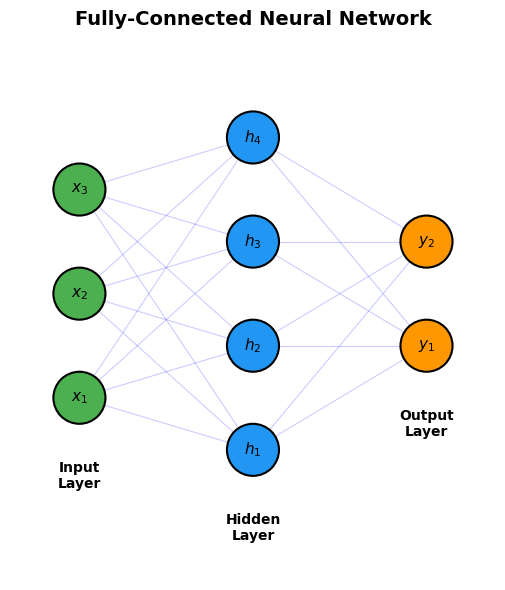

In [2]:
def draw_neural_network(layer_sizes, ax=None):
    """
    Draw a fully-connected neural network diagram.
    
    Parameters
    ----------
    layer_sizes : list of int
        Number of neurons in each layer, e.g. [3, 4, 2].
    ax : matplotlib Axes, optional
        Axes to draw on. If None, creates a new figure.
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    n_layers = len(layer_sizes)
    max_neurons = max(layer_sizes)
    
    # Spacing
    h_spacing = 2.0  # horizontal spacing between layers
    v_spacing = 1.2  # vertical spacing between neurons
    radius = 0.3
    
    # Compute positions for each neuron
    positions = []  # positions[layer][neuron] = (x, y)
    for i, size in enumerate(layer_sizes):
        layer_positions = []
        x = i * h_spacing
        y_start = (max_neurons - size) * v_spacing / 2  # center vertically
        for j in range(size):
            y = y_start + j * v_spacing
            layer_positions.append((x, y))
        positions.append(layer_positions)
    
    # Draw connections (edges) between consecutive layers
    for i in range(n_layers - 1):
        for (x1, y1) in positions[i]:
            for (x2, y2) in positions[i + 1]:
                ax.plot([x1, x2], [y1, y2], 'b-', alpha=0.2, linewidth=0.8)
    
    # Draw neurons (circles)
    layer_labels = ['Input\nLayer', 'Hidden\nLayer', 'Output\nLayer']
    if n_layers > 3:
        layer_labels = ['Input'] + [f'Hidden {i}' for i in range(1, n_layers - 1)] + ['Output']
    
    colors = ['#4CAF50', '#2196F3', '#FF9800']  # green, blue, orange
    if n_layers > 3:
        colors = ['#4CAF50'] + ['#2196F3'] * (n_layers - 2) + ['#FF9800']
    
    for i, layer_pos in enumerate(positions):
        color = colors[min(i, len(colors) - 1)]
        for j, (x, y) in enumerate(layer_pos):
            circle = plt.Circle((x, y), radius, color=color, ec='black',
                                linewidth=1.5, zorder=4)
            ax.add_patch(circle)
            # Label neuron
            if i == 0:
                ax.text(x, y, f'$x_{j+1}$', ha='center', va='center',
                        fontsize=11, fontweight='bold', zorder=5)
            elif i == n_layers - 1:
                ax.text(x, y, f'$y_{j+1}$', ha='center', va='center',
                        fontsize=11, fontweight='bold', zorder=5)
            else:
                ax.text(x, y, f'$h_{j+1}$', ha='center', va='center',
                        fontsize=11, fontweight='bold', zorder=5)
        
        # Layer label below
        x_center = positions[i][0][0]
        y_bottom = min(p[1] for p in positions[i]) - 0.9
        label = layer_labels[min(i, len(layer_labels) - 1)]
        ax.text(x_center, y_bottom, label, ha='center', va='center',
                fontsize=10, fontweight='bold')
    
    ax.set_xlim(-0.8, (n_layers - 1) * h_spacing + 0.8)
    ax.set_ylim(-1.5, max_neurons * v_spacing)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Fully-Connected Neural Network', fontsize=14, fontweight='bold')
    
    return ax


fig, ax = plt.subplots(1, 1, figsize=(10, 6))
draw_neural_network([3, 4, 2], ax=ax)
plt.tight_layout()
plt.show()
     

### Coding a single neuron

In [3]:
def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

def singlen(w,x,b,activation_fn=sigmoid):
    z=np.dot(w,x)+b
    a=activation_fn(z)
    return a,z

np.random.seed(42)
x=np.array([0.5,-0.8,-0.9])
w=np.random.randn(3)
b=np.random.randn()

a, z=singlen(w,x,b)

print(f"input x: {x}")
print(f"bias b: {b}")
print(f"weight w: {w}")
print(f"combined weight: {z}")
print(f"Output :{a}")

z_manual = w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b
a_manual = 1.0 / (1.0 + np.exp(-z_manual))
print(f"wieghted value is close: {np.isclose(z,z_manual)}") 
print(f"output value is close: {np.isclose(a,a_manual)}") 

input x: [ 0.5 -0.8 -0.9]
bias b: 1.5230298564080254
weight w: [ 0.49671415 -0.1382643   0.64768854]
combined weight: 1.2990786895599662
Output :0.7856798871717721
wieghted value is close: True
output value is close: True


### layers of neuron

In [4]:
def neuronlayer(w,x,b,activation_fn=sigmoid):
    z=w @ x+b
    a=activation_fn(z)
    return a,z

np.random.seed(42)
inputs=5
neurons=7

x=np.array([0.8,-0.7,1.4,2.7,-1.0])
w=np.random.randn(neurons,inputs)
b=np.random.randn(neurons)

a,z=neuronlayer(w,x,b)

print(f"shape of \n weights:{w.shape} \n inputs:{x.shape} \n bias:{b.shape} \n preactivation weigth:{z.shape} \n output:{a.shape}")

print(f"pre-activation weight :{z}")
print(f"output:{a}")

shape of 
 weights:(7, 5) 
 inputs:(5,) 
 bias:(7,) 
 preactivation weigth:(7,) 
 output:(7,)
pre-activation weight :[ 4.52641062 -1.81962721 -5.1065851  -1.66844932 -1.68047423  0.82884667
 -5.30385227]
output:[0.98929637 0.13947861 0.00602027 0.15863103 0.15703268 0.69611101
 0.0049478 ]


In [5]:
#verification
for i in range(neurons):
    aone,zone=singlen(w[i],x,b[i])
    print(f"{zone:.4f} and {aone:.4f} | {z[i]:.4f} and {a[i]:.4f}")

4.5264 and 0.9893 | 4.5264 and 0.9893
-1.8196 and 0.1395 | -1.8196 and 0.1395
-5.1066 and 0.0060 | -5.1066 and 0.0060
-1.6684 and 0.1586 | -1.6684 and 0.1586
-1.6805 and 0.1570 | -1.6805 and 0.1570
0.8288 and 0.6961 | 0.8288 and 0.6961
-5.3039 and 0.0049 | -5.3039 and 0.0049


### different activation function implementation

In [6]:
def Relu(z):
    return np.maximum(0,z)

def tanh(z):
    return np.tanh(z)

a,z=neuronlayer(w,x,b,Relu)
print("for Relu")
print(f"pre-activation weight :{z}")
print(f"output:{a}")
a,z=neuronlayer(w,x,b,tanh)
print("for tanh")
print(f"pre-a   ctivation weight :{z}")
print(f"output:{a}")

for Relu
pre-activation weight :[ 4.52641062 -1.81962721 -5.1065851  -1.66844932 -1.68047423  0.82884667
 -5.30385227]
output:[4.52641062 0.         0.         0.         0.         0.82884667
 0.        ]
for tanh
pre-a   ctivation weight :[ 4.52641062 -1.81962721 -5.1065851  -1.66844932 -1.68047423  0.82884667
 -5.30385227]
output:[ 0.99976591 -0.94880124 -0.99992663 -0.93134637 -0.93292307  0.67985624
 -0.99995055]


### forward Propogation

In [7]:
def sigmoid_derivative(z):
    s=sigmoid(z)
    return s*(1-s)

testz=np.array([1.0,2.0,3.0])
sigmoid_derivative(testz)

array([0.19661193, 0.10499359, 0.04517666])

### tanh

In [8]:
def tanhe(z):
    return np.tanh(z)

def derivative_tanh(z):
    return 1.0-tanh(z)**2

print(tanhe(testz))
print(derivative_tanh(testz))

[0.76159416 0.96402758 0.99505475]
[0.41997434 0.07065082 0.00986604]


### Relu

In [9]:
def Relu(z):
    return np.maximum(0,z)

def derivative_relu(z):
    return (z>0).astype(float)

### Leaky Relu

In [10]:
def lrelu(z):
    return np.where(z>0,z,0.01*z)

def dlrelu(z):
    return np.where(z>0,1,0.01)

print(lrelu(z))
print(dlrelu(z))

[ 4.52641062 -0.01819627 -0.05106585 -0.01668449 -0.01680474  0.82884667
 -0.05303852]
[1.   0.01 0.01 0.01 0.01 1.   0.01]


### Gellu function

In [11]:
def gelu(z):
    return 0.5*z*(1.0+np.tanh(np.sqrt(2/np.pi)*(z*0.044915+z**3)))

a=gelu(z)
print(a)


[ 4.52641062e+00 -1.06630693e-04 -0.00000000e+00 -8.94024817e-04
 -7.65650053e-04  6.00690320e-01 -0.00000000e+00]


### graph of activation function and derivative

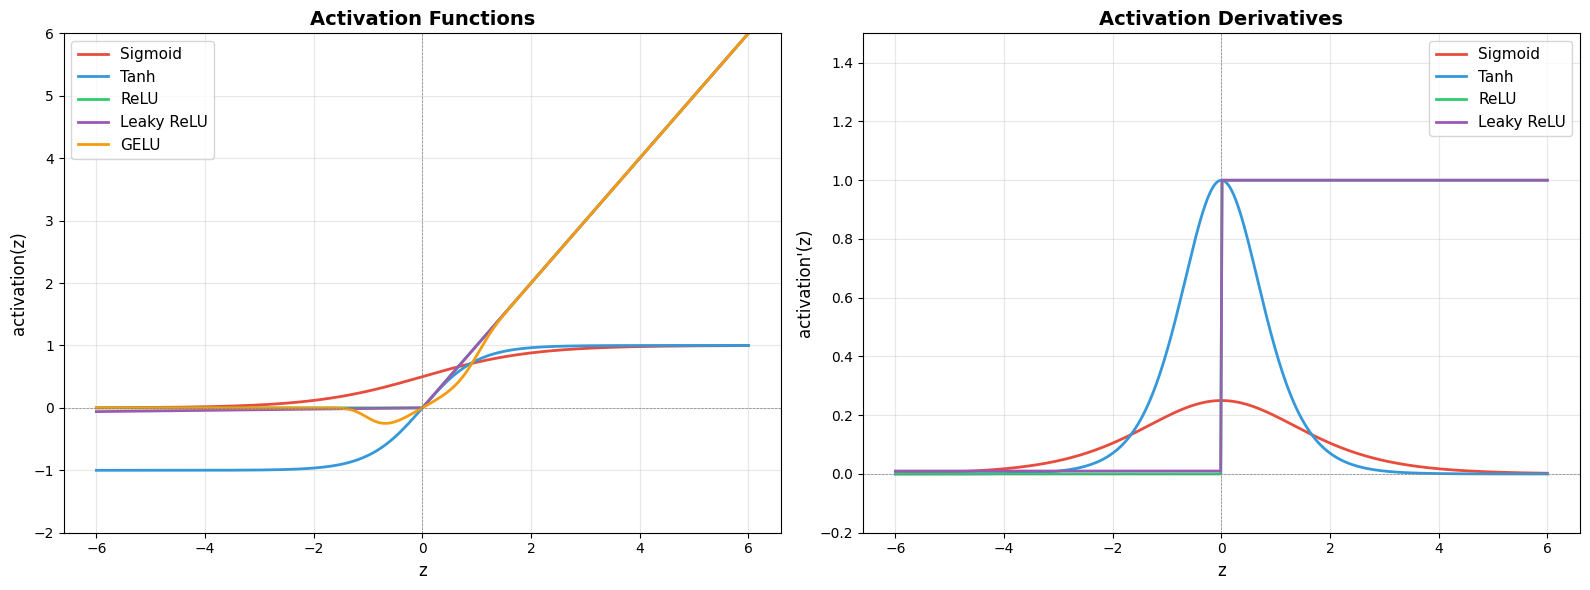

In [12]:
z = np.linspace(-6, 6, 500)

activations = {
    'Sigmoid': (sigmoid, sigmoid_derivative),
    'Tanh': (tanhe, derivative_tanh),
    'ReLU': (Relu, derivative_relu),
    'Leaky ReLU': (lrelu, dlrelu),
    'GELU': (gelu, None),  # derivative omitted for brevity
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot activation functions ---
ax = axes[0]
for (name, (fn, _)), color in zip(activations.items(), colors):
    ax.plot(z, fn(z), label=name, color=color, linewidth=2)

ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('activation(z)', fontsize=12)
ax.set_title('Activation Functions', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(-2, 6)
ax.grid(True, alpha=0.3)

# --- Plot derivatives ---
ax = axes[1]
derivs = {
    'Sigmoid': (sigmoid_derivative, '#e74c3c'),
    'Tanh': (derivative_tanh, '#3498db'),
    'ReLU': (derivative_relu, '#2ecc71'),
    'Leaky ReLU': (dlrelu, '#9b59b6'),
}
for name, (fn, color) in derivs.items():
    ax.plot(z, fn(z), label=name, color=color, linewidth=2)

ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel("activation'(z)", fontsize=12)
ax.set_title('Activation Derivatives', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(-0.2, 1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### forwardpropogation with tow layers

In [ ]:
def forward_prop_2layers(x,w1,w2,b1,b2):
    z1=x@w1.T+b1
    a1=Relu(z1)
    z2=a1@w2.T+b2
    a2=sigmoid(z2)
    cache={
        'x':x,
        'z1':z1,
        'z2':z2,
        'a1':a1,
        'a2':a2
    }
    return cache,a2

np.random.seed(42)
n_input,n_hidden,n_output=3,4,1
w1=np.random.randn(n_hidden,n_input)*np.sqrt(2/n_input)
b1=np.zeros(n_hidden)
w2=np.random.randn(n_output,n_hidden)
b2=np.zeros(n_output)

x=np.array([
    [0.5,-0.4,0.3],
    [-0.8,4.0,-0.6],
    [0.2,3.4,-0.8]
])

cache,a2=forward_prop_2layers(x,w1,w2,b1,b2)
print(f'input values: {cache['x']}')
print(f'first hidden layer weighted value:{cache['z1']}')
print(f'activation value after hidden layer:{cache['a1']}')
print(f'give output combined weigth:{cache['z2']}')
for i in range(len(a2)):
    print(f'sample {i}:{a2[i,0]:.4f}')


input values: [[ 0.5 -0.4  0.3]
 [-0.8  4.  -0.6]
 [ 0.2  3.4 -0.8]]
first hidden layer weighted value:[[ 0.40659028  0.6408969   0.27907053  0.25877077]
 [-1.09332293 -1.64487744  1.70488838 -1.63975453]
 [-0.72578922 -0.24838311  2.69501039 -0.89367538]]
activation value after hidden layer:[[0.40659028 0.6408969  0.27907053 0.25877077]
 [0.         0.         1.70488838 0.        ]
 [0.         0.         2.69501039 0.        ]]
give output combined weigth:[[-1.75471318]
 [-2.94079236]
 [-4.64867148]]
sample0:0.1475
sample1:0.0502
sample2:0.0095


### Backpropogation